In [1]:
import sys
import torch
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset, ConcatDataset, Subset
from torchvision.utils import make_grid
import torch.nn.functional as F


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import random

vae_path = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/Bingji_code"
sys.path.append(vae_path)

import models as models
import train_helper as train_helper
import utils as utils
import data_helper as data_helper


In [2]:
# Set up device and seed
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
base_seed = 0
torch.manual_seed(base_seed)
torch.cuda.manual_seed_all(base_seed)
np.random.seed(base_seed)
random.seed(base_seed)

model_saved_path = os.path.join(os.getcwd(),"model_saved")
data_saved_path = os.path.join(os.getcwd(),"data_saved")
results_saved_path = os.path.join(os.getcwd(),"results_saved")

In [28]:
os.getcwd()

'/home/qiyuanliu'

## Prepare data ##


In [3]:
full_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transforms.ToTensor())

test_dataset = datasets.MNIST(root="./data", train=False, download=True,transform=transforms.ToTensor())
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)
full_digit_indices = utils.create_balanced_subset_indices(full_dataset,seed=base_seed)

#train_dataset_5000 = Subset(full_dataset, range(5000))

# FID

In [ ]:
import torch
import torch.nn.functional as F

@torch.no_grad()
def generate_images_in_batches(model, total_samples, latent_dim, num_classes, batch_size=10000, device='cuda'):
    model.eval()
    generated_images = []
    all_labels = []

    # Balanced label assignment (always length = total_samples)
    labels_full = torch.arange(total_samples) % num_classes

    for start in range(0, total_samples, batch_size):
        end = min(start + batch_size, total_samples)
        n = end - start

        # Sample latent z
        z = torch.randn(n, latent_dim, device=device)

        # Labels
        y = labels_full[start:end]
        y_onehot = F.one_hot(y, num_classes=num_classes).float().to(device)

        # Decode logits → sigmoid → [0,1]
        logits_flat = model.decoder.decode(z, y_onehot)     # (n, 784), logits
        imgs = torch.sigmoid(logits_flat).view(-1, 1, 28, 28).cpu()

        generated_images.append(imgs)
        all_labels.append(y)

    images = torch.cat(generated_images, dim=0)
    labels = torch.cat(all_labels, dim=0)
    return images, labels

from FID import calculate_fid_score

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

@torch.no_grad()
def plot_model_samples(model, save_path=None, latent_dim=20, num_classes=10, per_class=8, device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device).eval()

    # latent + labels
    z = torch.randn(num_classes * per_class, latent_dim, device=device)
    y = torch.arange(num_classes, device=device).repeat_interleave(per_class)
    y_onehot = F.one_hot(y, num_classes=num_classes).float().to(device)

    # decode -> logits, then map to [0,1]
    logits_flat = model.decoder.decode(z, y_onehot)            # (n, 784), logits
    imgs = torch.sigmoid(logits_flat).view(-1, 1, 28, 28)      # tensor on device, no grad (due to @no_grad)

    # move for plotting
    imgs_np = imgs.detach().cpu().numpy()

    fig, axes = plt.subplots(num_classes, per_class, figsize=(2*per_class, 2*num_classes))
    for c in range(num_classes):
        for j in range(per_class):
            idx = c * per_class + j
            axes[c, j].imshow(imgs_np[idx].squeeze(), cmap='gray')
            axes[c, j].axis('off')
            if j == 0:
                axes[c, j].set_ylabel(f"Class {c}", fontsize=10)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
        print(f"[SAVE] Sample grid saved -> {save_path}")
    return fig, axes


def fid(model):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    synthetic_gen_size = 6000
    gen_imgs_before_filter,y_before_filter = generate_images_in_batches(
        model=model,
        total_samples=synthetic_gen_size,
        latent_dim=20,
        num_classes=10,
        batch_size=10000,
        device=device
    )
    # Load synthetic data
    #synthetic = torch.load(f"data_saved/synthetic_mnist_cvae_{sample_size}_2.pt")
    images = gen_imgs_before_filter # [N, 1, 28, 28]
    labels = y_before_filter  # [N]

    transform = transforms.ToTensor()

    real_ds = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
    synthetic_ds = TensorDataset(images, labels)
    
    synthetic_ds = TensorDataset(images, labels)
    fid = calculate_fid_score(real_ds, synthetic_ds)
    
    return fid



## Reproduce synthetic data retraining improving testing error

In [30]:
import shutil

init_size = 500

all_models = []
test_results = {"val_loss":[], "val_recon":[], "val_kl":[], "fid":[],"model_name":[]}

# Seed real subset & train initial model
init_subset = utils.get_balanced_subset(full_digit_indices, init_size)
init_dataset = Subset(full_dataset, init_subset)
init_loader = DataLoader(init_dataset, batch_size=128, shuffle=True)

this_model = models.CVAE(input_dim=784, label_dim=10, latent_dim=20,
                         name=f"cvae_conv_real_{init_size}", arch="conv").to(device)
train_helper.train_model(this_model, init_loader, device, epochs=1, lr=1e-3, patience=5, verbose=False)

val_loss, val_recon, val_kl = train_helper.calculate_validation_loss(this_model, test_loader, device)
fid_score = fid(this_model)
test_results["val_loss"].append(val_loss)
test_results["val_recon"].append(val_recon)
test_results["val_kl"].append(val_kl)
test_results["fid"].append(fid_score)
test_results["model_name"].append(this_model.name)
print(f"Init loss: {init_size} - Val Loss: {val_loss:.4f} - Val KL: {val_kl:.4f} - Val Recon: {val_recon:.4f}")
all_models.append(this_model)

utils.save_model(this_model, this_model.get_name(), model_saved_path)

# ----- k-round synthetic retraining -----
k = 3                      # <-- number of retraining rounds
threshold = 0.1           # discriminator selection threshold
synthetic_size = 200_000         # list of synthetic attempt sizes to run per round

curr_model = this_model
for round_id in range(1, k + 1):
    # (A) Train a fresh discriminator for the CURRENT generator
    print(f"\n[Round {round_id}] Training discriminator for current model...")
    discriminator_dataset = data_helper.prepare_discriminator_dataset(full_dataset, curr_model, device)
    disc_loader = DataLoader(discriminator_dataset, batch_size=128, shuffle=True)
    disc_model = models.SyntheticDiscriminator(input_dim=784).to(device)
    train_helper.train_model(model=disc_model, train_loader=disc_loader, device=device,
                             epochs=1, lr=1e-3, patience=5, verbose=False)
    del disc_loader, discriminator_dataset
    # (B) Generate filtered synthetic dataset to a TEMP dir (unique per round)
    model_name = f'cvae_conv_q{threshold}_{synthetic_size}_r{round_id}'
    synthetic_data_load_path = os.path.join(data_saved_path, model_name)

    print(f"[Round {round_id}] Generating filtered synthetic data -> {synthetic_data_load_path}")
    data_helper.generate_balanced_images_with_filtering(
        model=curr_model,
        save_directory=synthetic_data_load_path,
        total_samples=synthetic_size,
        discriminator=disc_model,
        selection_threshold=threshold,
        verbose=False,
        use_quantile_filtering=True
    )

    synthetic_loader = data_helper.create_directory_based_dataloader(synthetic_data_load_path, batch_size=128)
    synthetic_model = models.CVAE(input_dim=784, label_dim=10, latent_dim=20,
                                    name=model_name, arch="conv").to(device)
    train_helper.train_model(synthetic_model, synthetic_loader, device,
                                epochs=1, lr=1e-3, patience=5, verbose=False)

    val_loss, val_recon, val_kl = train_helper.calculate_validation_loss(synthetic_model, test_loader, device)
    fid_score = fid(synthetic_model)
    test_results["val_loss"].append(val_loss)
    test_results["val_recon"].append(val_recon)
    test_results["val_kl"].append(val_kl)
    test_results["model_name"].append(synthetic_model.get_name())
    test_results["fid"].append(fid_score)
    print(f"[Round {round_id}] Model: {model_name} | Val Loss: {val_loss:.4f} | KL: {val_kl:.4f} | Recon: {val_recon:.4f} | FID: {fid_score:.4f}")

    utils.save_model(synthetic_model, synthetic_model.get_name(), model_saved_path)
    all_models.append(synthetic_model)

    # (D) Advance the chain
    curr_model = synthetic_model

    # (E) Cleanup temp dir
    del synthetic_loader
    try:
        if os.path.exists(synthetic_data_load_path):
            shutil.rmtree(synthetic_data_load_path)
            print(f"[CLEAN] Removed temp dir: {synthetic_data_load_path}")
    except Exception as e:
        print(f"[WARN] Failed to remove {synthetic_data_load_path}: {e}")

    # Optional: free GPU cache between rounds
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# Results table
res_table = pd.DataFrame.from_dict(test_results, orient='columns')


Init loss: 500 - Val Loss: 480.9599 - Val KL: 2.8418 - Val Recon: 478.1181
Model saved to /home/qiyuanliu/model_saved/cvae_conv_real_500.pth

[Round 1] Training discriminator for current model...
[Round 1] Generating filtered synthetic data -> /home/qiyuanliu/data_saved/cvae_conv_q0.1_200000_r1


/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/Bingji_code/data_helper.py:73: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  file_data = torch.load(file_path, map_

[Round 1] Model: cvae_conv_q0.1_200000_r1 | Val Loss: 485.9144 | KL: 0.6749 | Recon: 485.2395 | FID: 354.9685
Model saved to /home/qiyuanliu/model_saved/cvae_conv_q0.1_200000_r1.pth

[Round 2] Training discriminator for current model...
[Round 2] Generating filtered synthetic data -> /home/qiyuanliu/data_saved/cvae_conv_q0.1_200000_r2
[Round 2] Model: cvae_conv_q0.1_200000_r2 | Val Loss: 458.9648 | KL: 1.1241 | Recon: 457.8407 | FID: 345.5407
Model saved to /home/qiyuanliu/model_saved/cvae_conv_q0.1_200000_r2.pth

[Round 3] Training discriminator for current model...
[Round 3] Generating filtered synthetic data -> /home/qiyuanliu/data_saved/cvae_conv_q0.1_200000_r3
[Round 3] Model: cvae_conv_q0.1_200000_r3 | Val Loss: 459.4273 | KL: 1.8226 | Recon: 457.6047 | FID: 350.6169
Model saved to /home/qiyuanliu/model_saved/cvae_conv_q0.1_200000_r3.pth


In [17]:
print(res_table)
# res_table.to_csv(os.path.join(results_saved_path, 'conv_q_combine_size_results.csv'), index=False, mode='a', header=False)

     val_loss  val_recon     val_kl             model_name
0  119.708937  95.647302  24.061635     cvae_conv_real_500
1  109.797275  87.217765  22.579511  cvae_conv_q0.1_200000


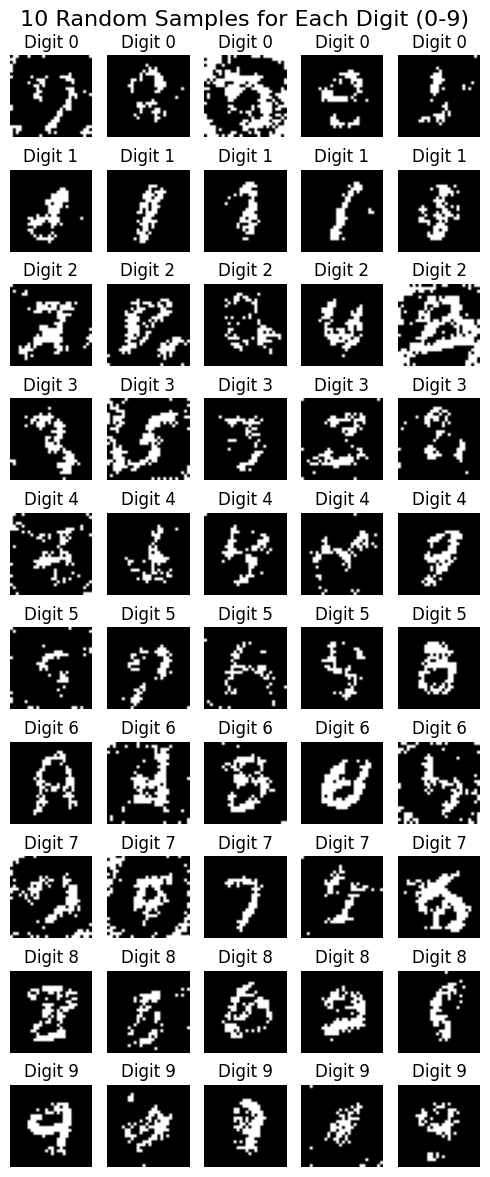

In [18]:
utils.plot_samples_per_digit(5,all_models[0])

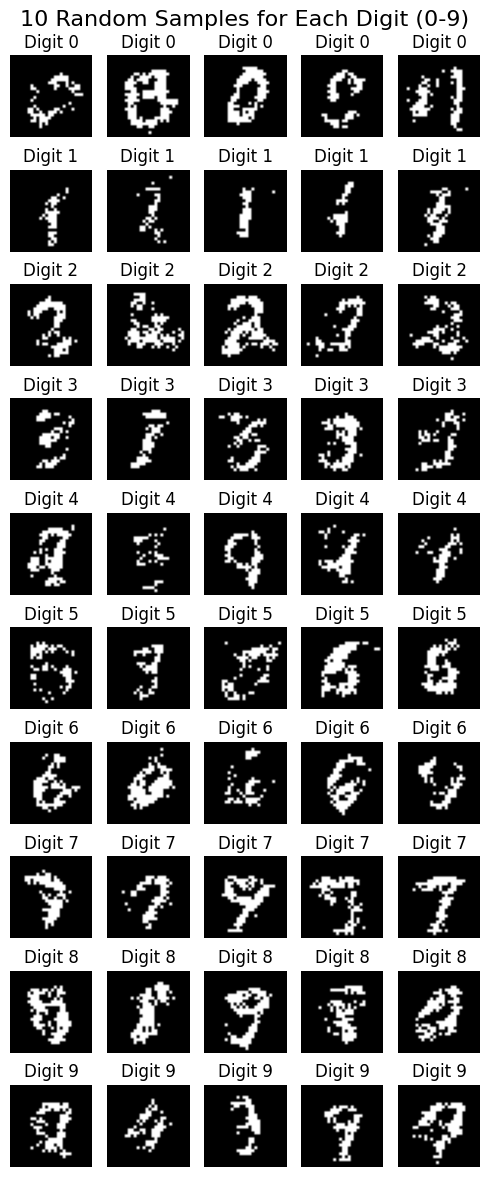

In [19]:
utils.plot_samples_per_digit(5,all_models[-1])

# FID

In [20]:
import torch
import torch.nn.functional as F

@torch.no_grad()
def generate_images_in_batches(model, total_samples, latent_dim, num_classes, batch_size=10000, device='cuda'):
    model.eval()
    generated_images = []
    all_labels = []

    # Balanced label assignment (always length = total_samples)
    labels_full = torch.arange(total_samples) % num_classes

    for start in range(0, total_samples, batch_size):
        end = min(start + batch_size, total_samples)
        n = end - start

        # Sample latent z
        z = torch.randn(n, latent_dim, device=device)

        # Labels
        y = labels_full[start:end]
        y_onehot = F.one_hot(y, num_classes=num_classes).float().to(device)

        # Decode logits → sigmoid → [0,1]
        logits_flat = model.decoder.decode(z, y_onehot)     # (n, 784), logits
        imgs = torch.sigmoid(logits_flat).view(-1, 1, 28, 28).cpu()

        generated_images.append(imgs)
        all_labels.append(y)

    images = torch.cat(generated_images, dim=0)
    labels = torch.cat(all_labels, dim=0)
    return images, labels


In [21]:
from FID import calculate_fid_score

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

@torch.no_grad()
def plot_model_samples(model, save_path=None, latent_dim=20, num_classes=10, per_class=8, device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device).eval()

    # latent + labels
    z = torch.randn(num_classes * per_class, latent_dim, device=device)
    y = torch.arange(num_classes, device=device).repeat_interleave(per_class)
    y_onehot = F.one_hot(y, num_classes=num_classes).float().to(device)

    # decode -> logits, then map to [0,1]
    logits_flat = model.decoder.decode(z, y_onehot)            # (n, 784), logits
    imgs = torch.sigmoid(logits_flat).view(-1, 1, 28, 28)      # tensor on device, no grad (due to @no_grad)

    # move for plotting
    imgs_np = imgs.detach().cpu().numpy()

    fig, axes = plt.subplots(num_classes, per_class, figsize=(2*per_class, 2*num_classes))
    for c in range(num_classes):
        for j in range(per_class):
            idx = c * per_class + j
            axes[c, j].imshow(imgs_np[idx].squeeze(), cmap='gray')
            axes[c, j].axis('off')
            if j == 0:
                axes[c, j].set_ylabel(f"Class {c}", fontsize=10)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
        print(f"[SAVE] Sample grid saved -> {save_path}")
    return fig, axes


def fid(model):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    synthetic_gen_size = 6000
    gen_imgs_before_filter,y_before_filter = generate_images_in_batches(
        model=model,
        total_samples=synthetic_gen_size,
        latent_dim=20,
        num_classes=10,
        batch_size=10000,
        device=device
    )
    # Load synthetic data
    #synthetic = torch.load(f"data_saved/synthetic_mnist_cvae_{sample_size}_2.pt")
    images = gen_imgs_before_filter # [N, 1, 28, 28]
    labels = y_before_filter  # [N]

    transform = transforms.ToTensor()

    real_ds = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
    synthetic_ds = TensorDataset(images, labels)
    
    synthetic_ds = TensorDataset(images, labels)
    fid = calculate_fid_score(real_ds, synthetic_ds)
    
    return fid


In [22]:
model0_fid = fid(all_models[0])
model_synthetic_fid = fid(all_models[-1])

In [27]:
model0_fid, model_synthetic_fid

(99.47520446777344, 73.43175506591797)

(<Figure size 1600x2000 with 80 Axes>,
 array([[<Axes: ylabel='Class 0'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='Class 1'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='Class 2'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='Class 3'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='Class 4'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='Class 5'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='Class 6'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='Class 7'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='Class 8'>, <Axes:

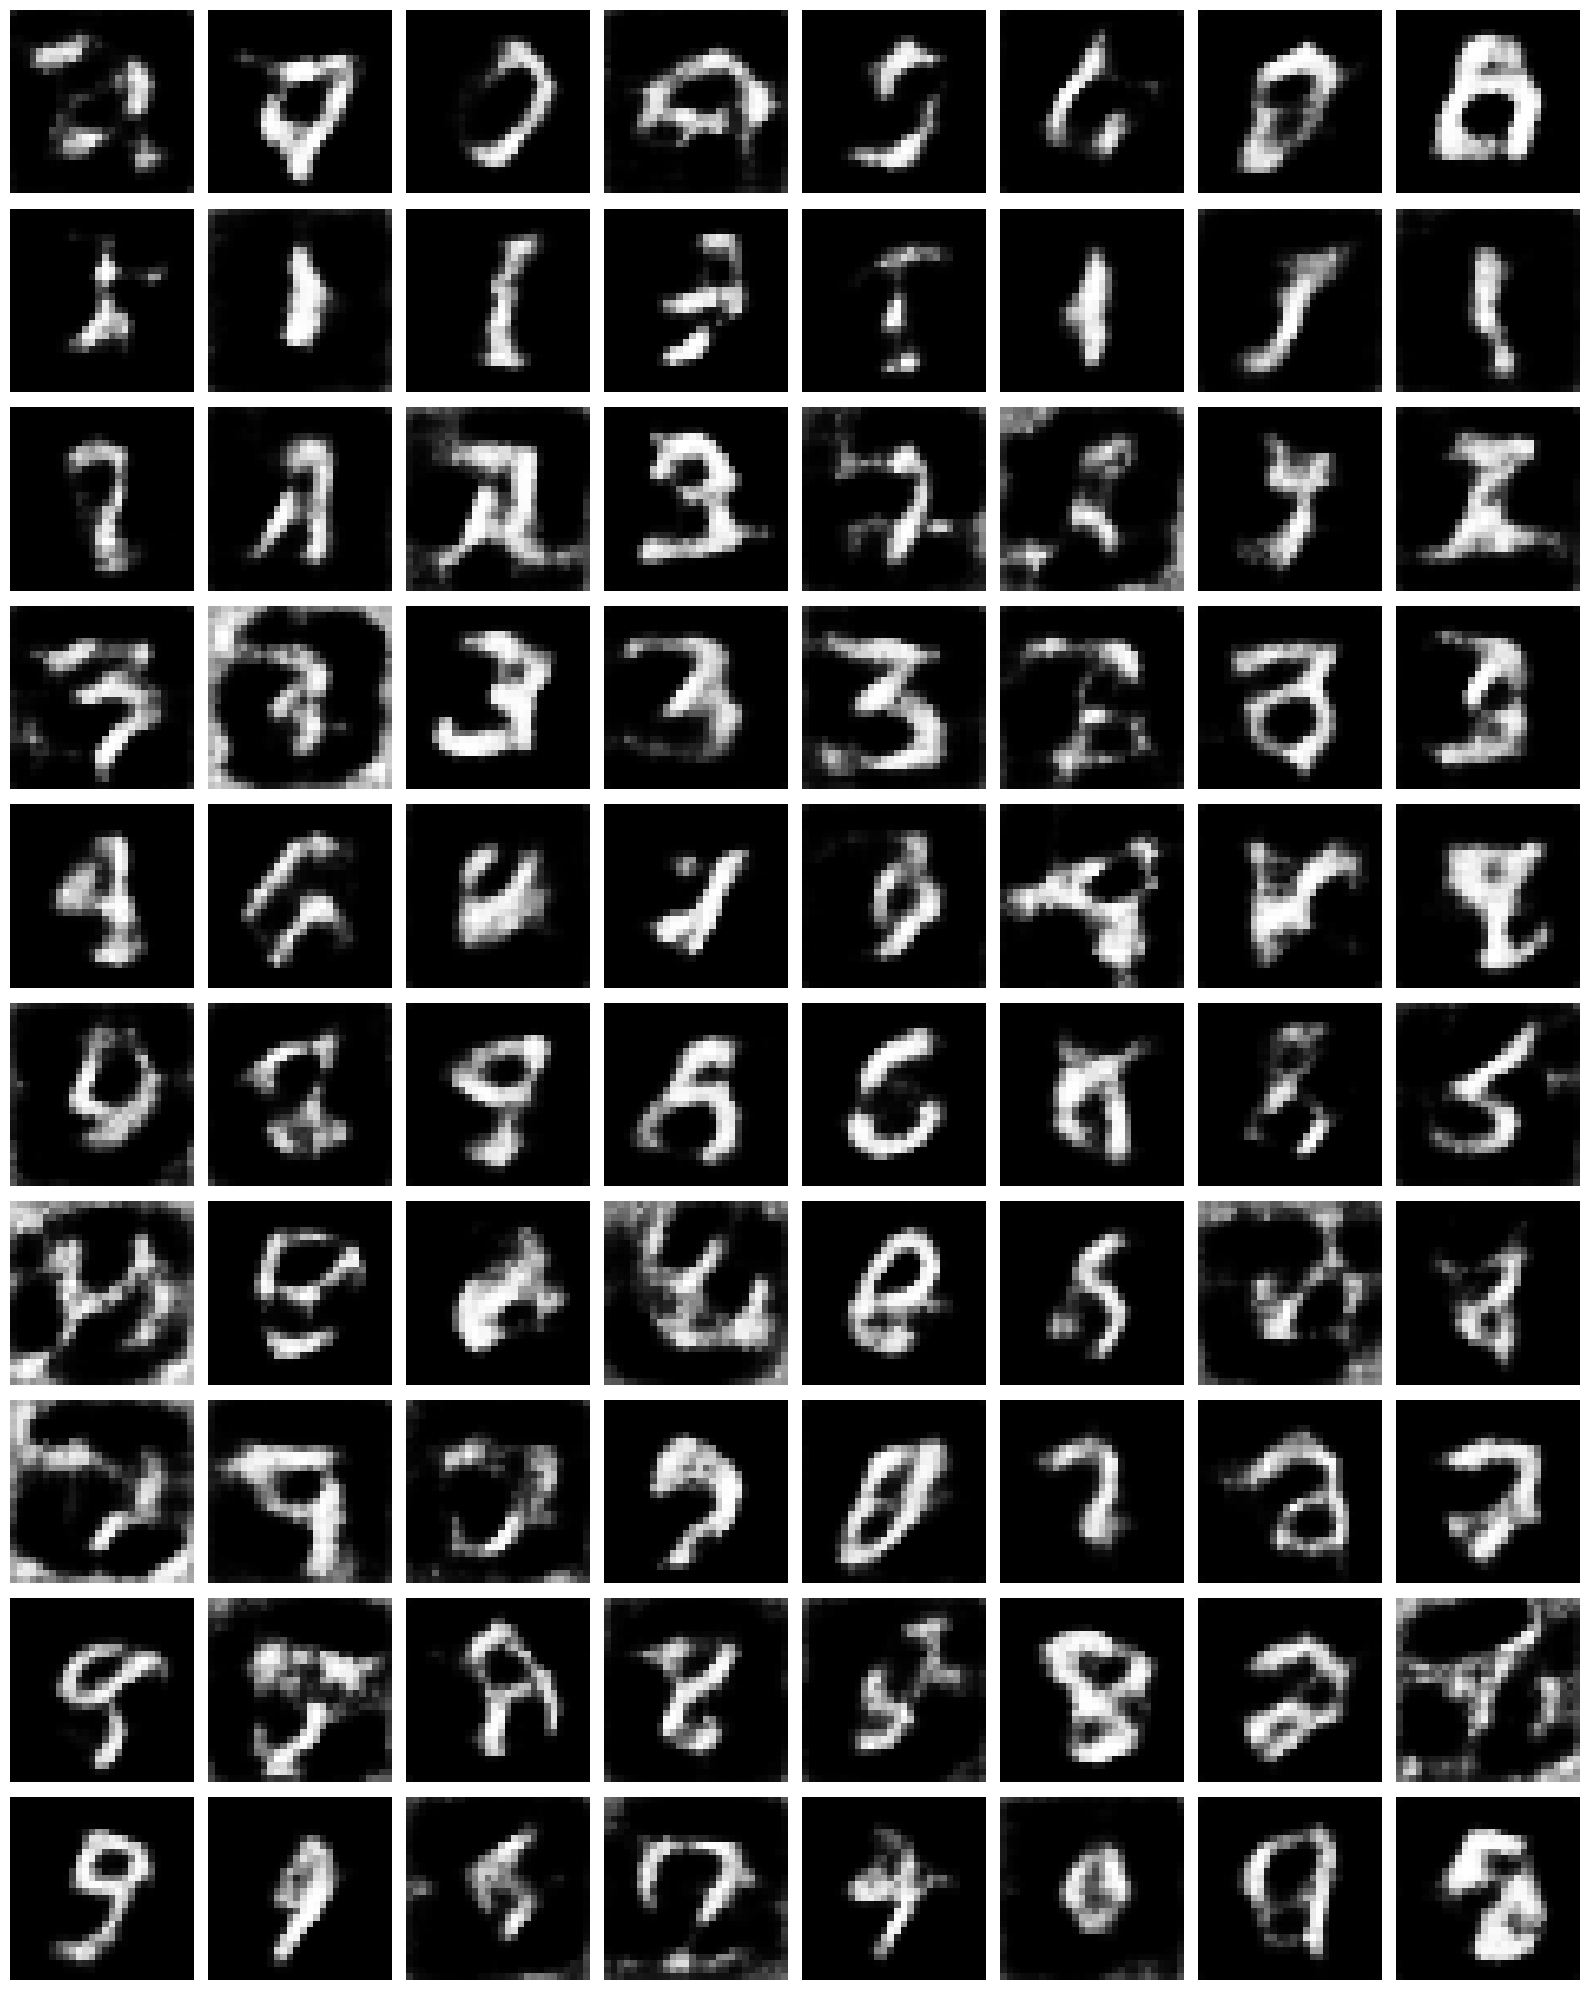

In [24]:
plot_model_samples(all_models[0])

(<Figure size 1600x2000 with 80 Axes>,
 array([[<Axes: ylabel='Class 0'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='Class 1'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='Class 2'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='Class 3'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='Class 4'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='Class 5'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='Class 6'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='Class 7'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='Class 8'>, <Axes:

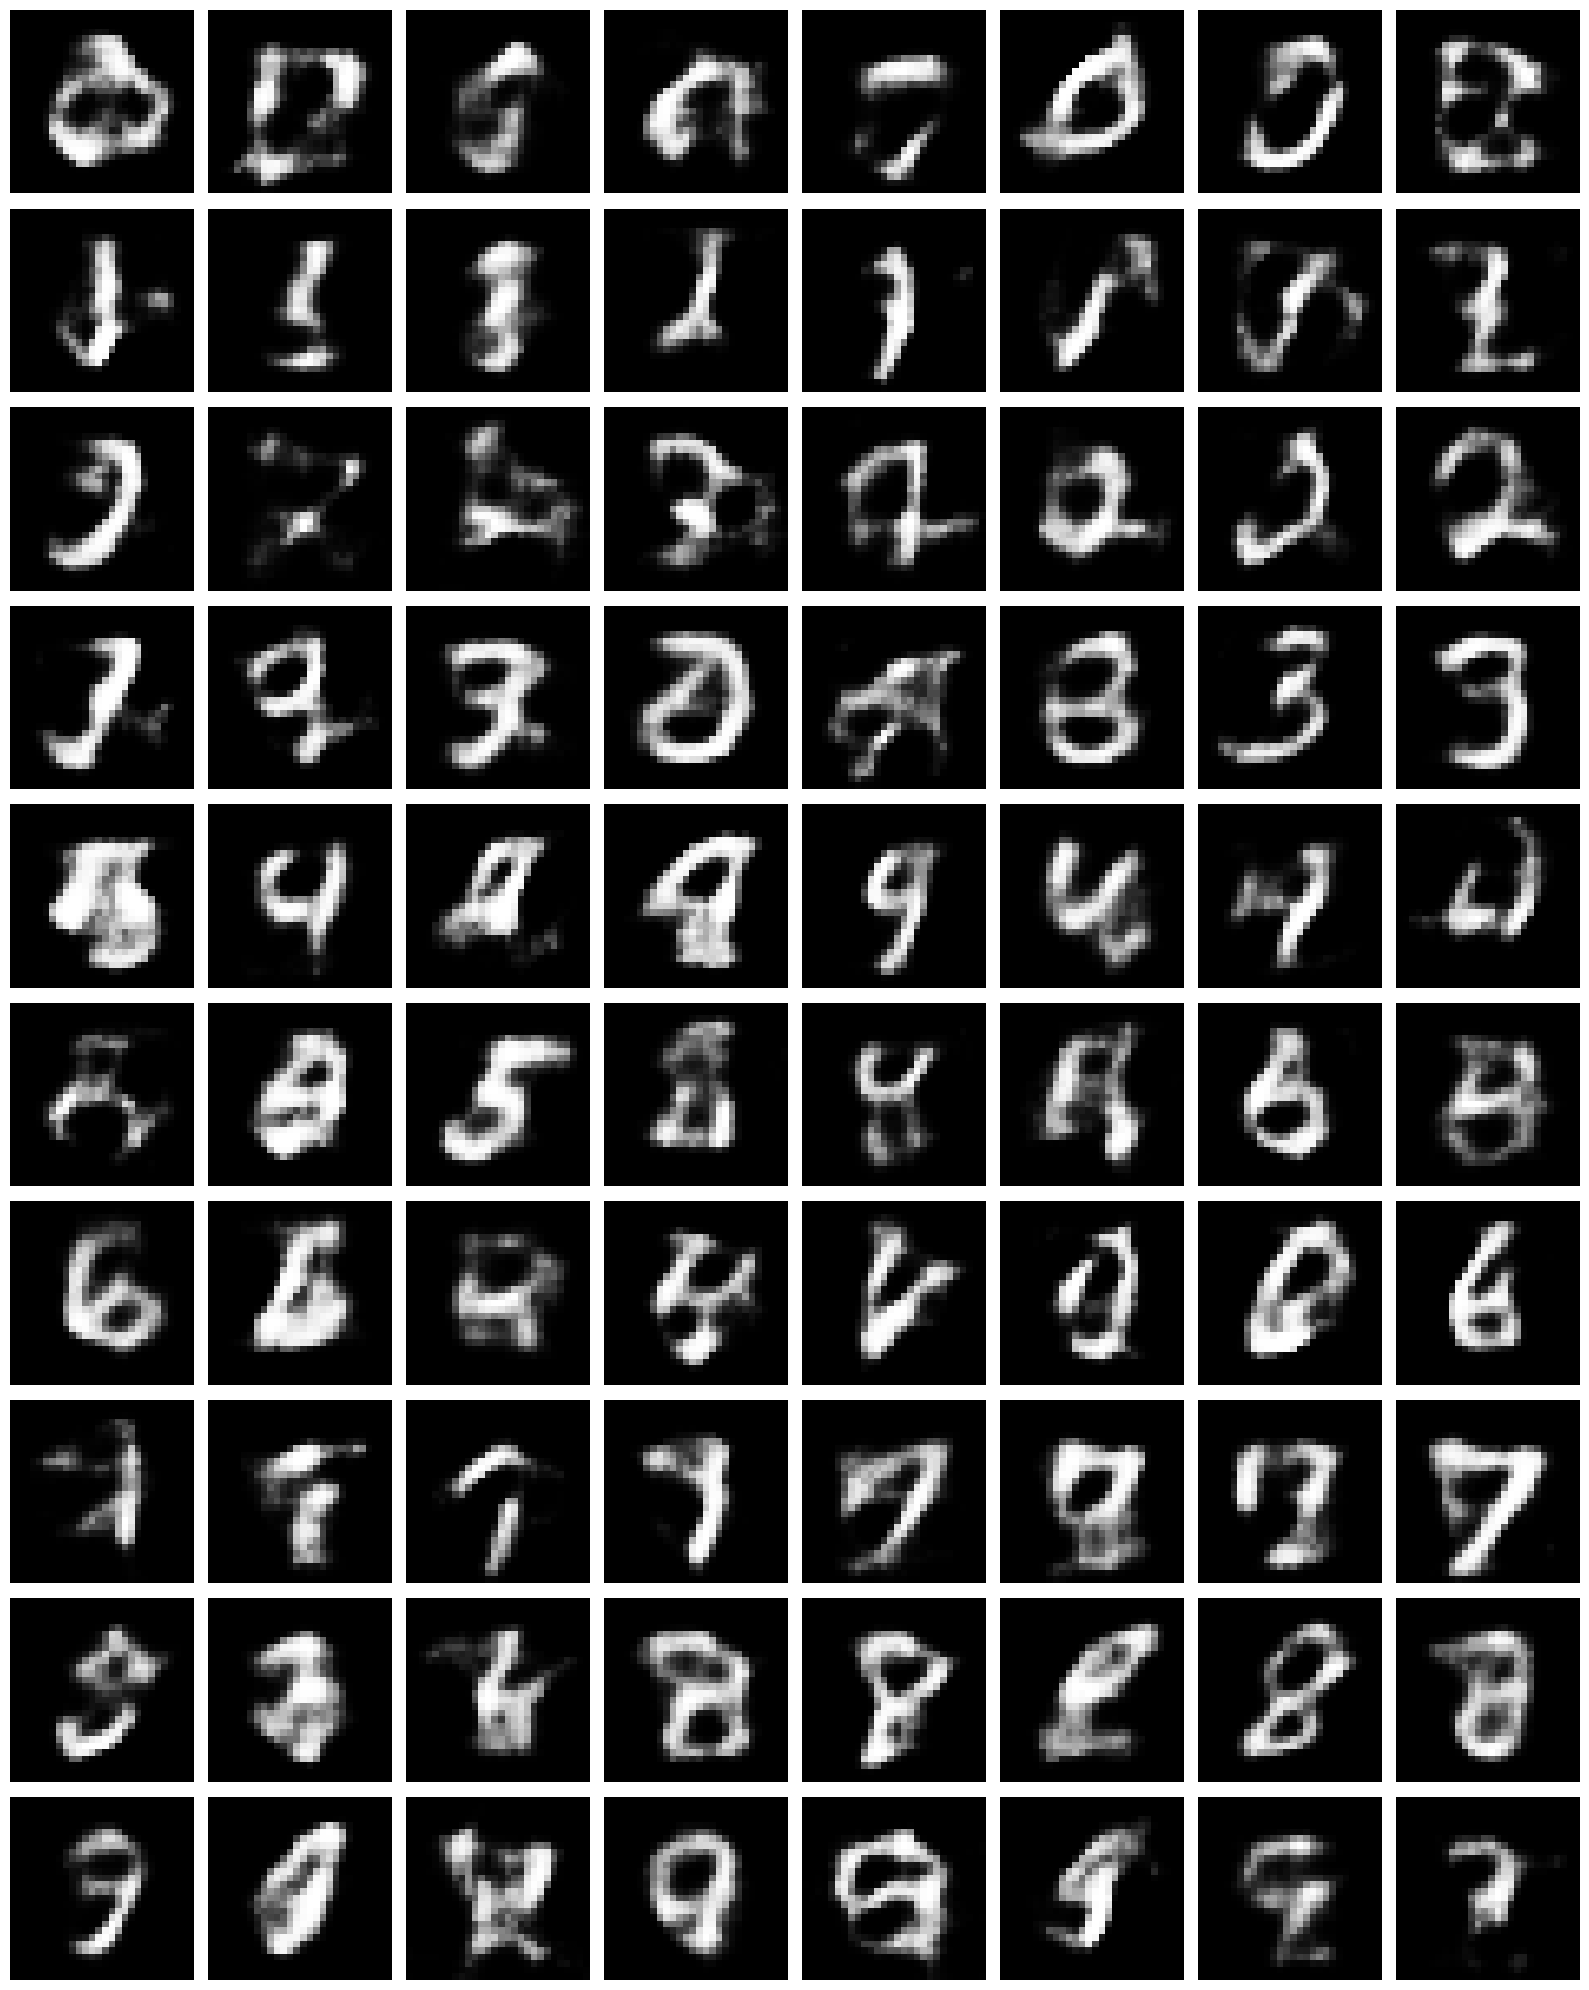

In [26]:
plot_model_samples(all_models[-1])

[SAVE] Sample grid saved -> /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/Bingji_code/picture_saved/initial_model_samples_500.png
Init loss: 500 - Val Loss: 508.1297 - Val KL: 2.9830 - Val Recon: 505.1467
Model saved to /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/Bingji_code/model_saved/cvae_conv_real_500.pth

[Round 1] Training discriminator for current model...
[Round 1] Generating filtered synthetic data -> /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/Bingji_code/data_saved/cvae_conv_q0.1_200000_r1


/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/Bingji_code/data_helper.py:73: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  file_data = torch.load(file_path, map_

[SAVE] Sample grid saved -> /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/Bingji_code/picture_saved/round1_model_samples.png
[Round 1] Model: cvae_conv_q0.1_200000_r1 | Val Loss: 483.4756 | KL: 2.2093 | Recon: 481.2663 | FID: 376.4771
Model saved to /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/Bingji_code/model_saved/cvae_conv_q0.1_200000_r1.pth

[Round 2] Training discriminator for current model...
[Round 2] Generating filtered synthetic data -> /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/Bingji_code/data_saved/cvae_conv_q0.1_200000_r2
[SAVE] Sample grid saved -> /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/Bingji_code/picture_saved/round2_model_samples.png
[Round 2] Model: cvae_conv_q0.1_200000_r2 | Val Loss: 460.5670 | KL: 2.2274 | Recon: 458.3396 | FID: 363.5699
Model saved to /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/Bingji_code/model_saved/cvae_conv_q0.1_200000_r2.pth

[Round 3] Training discriminator for current

OSError: Cannot save file into a non-existent directory: '/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/Bingji_code/results_saved'

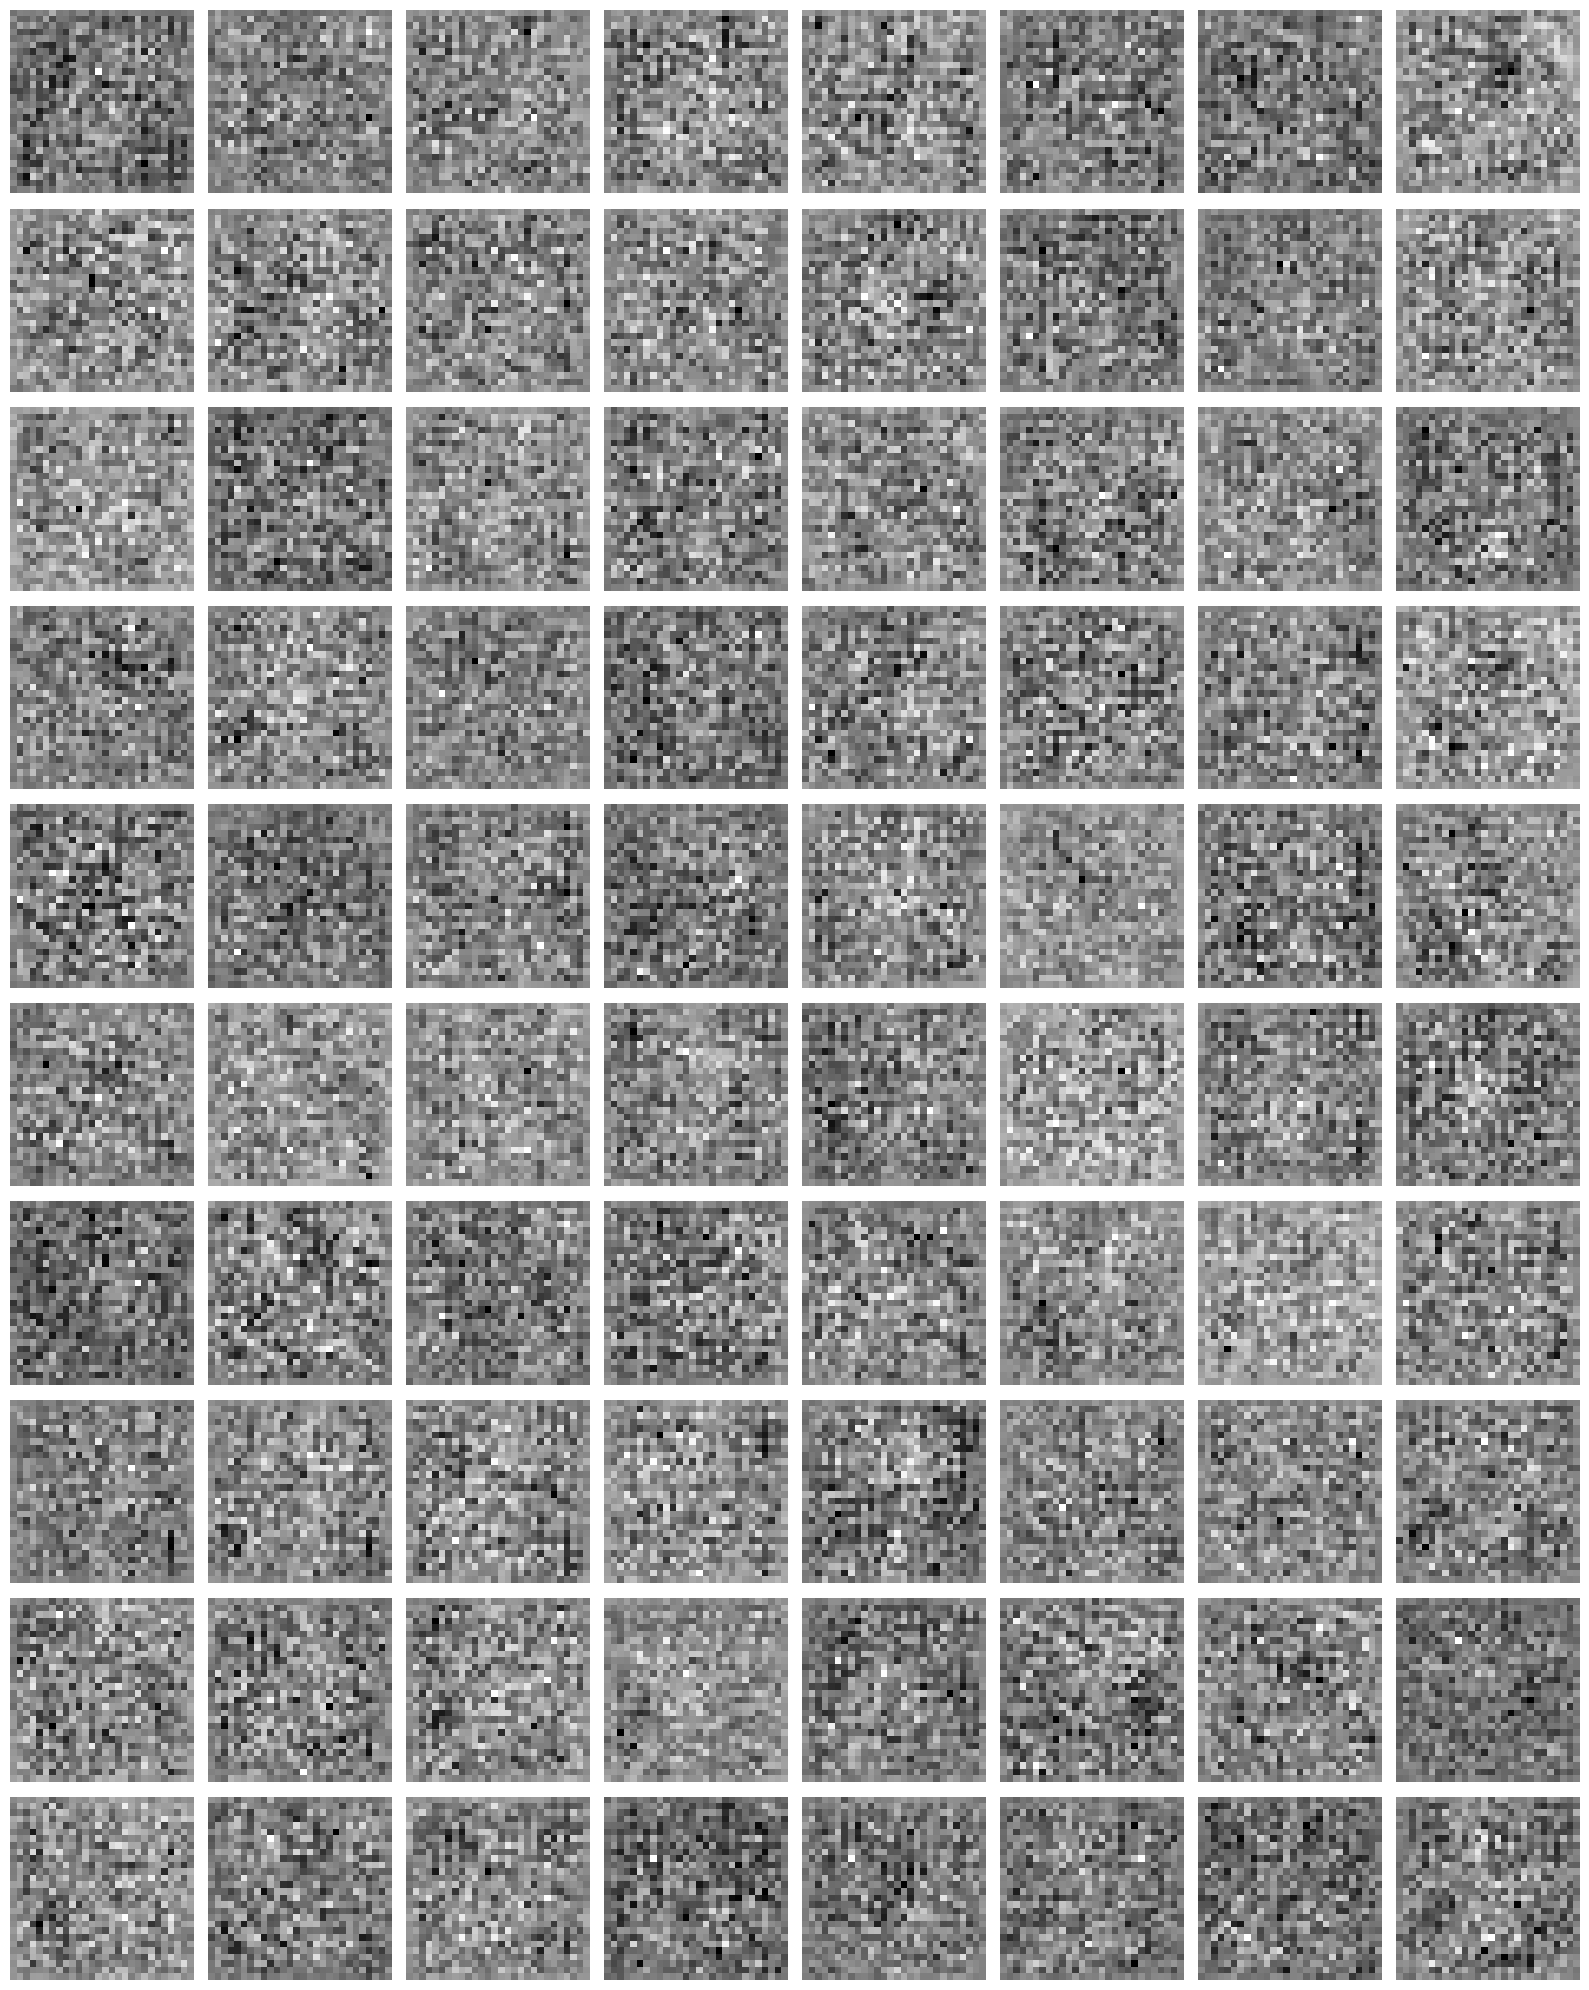

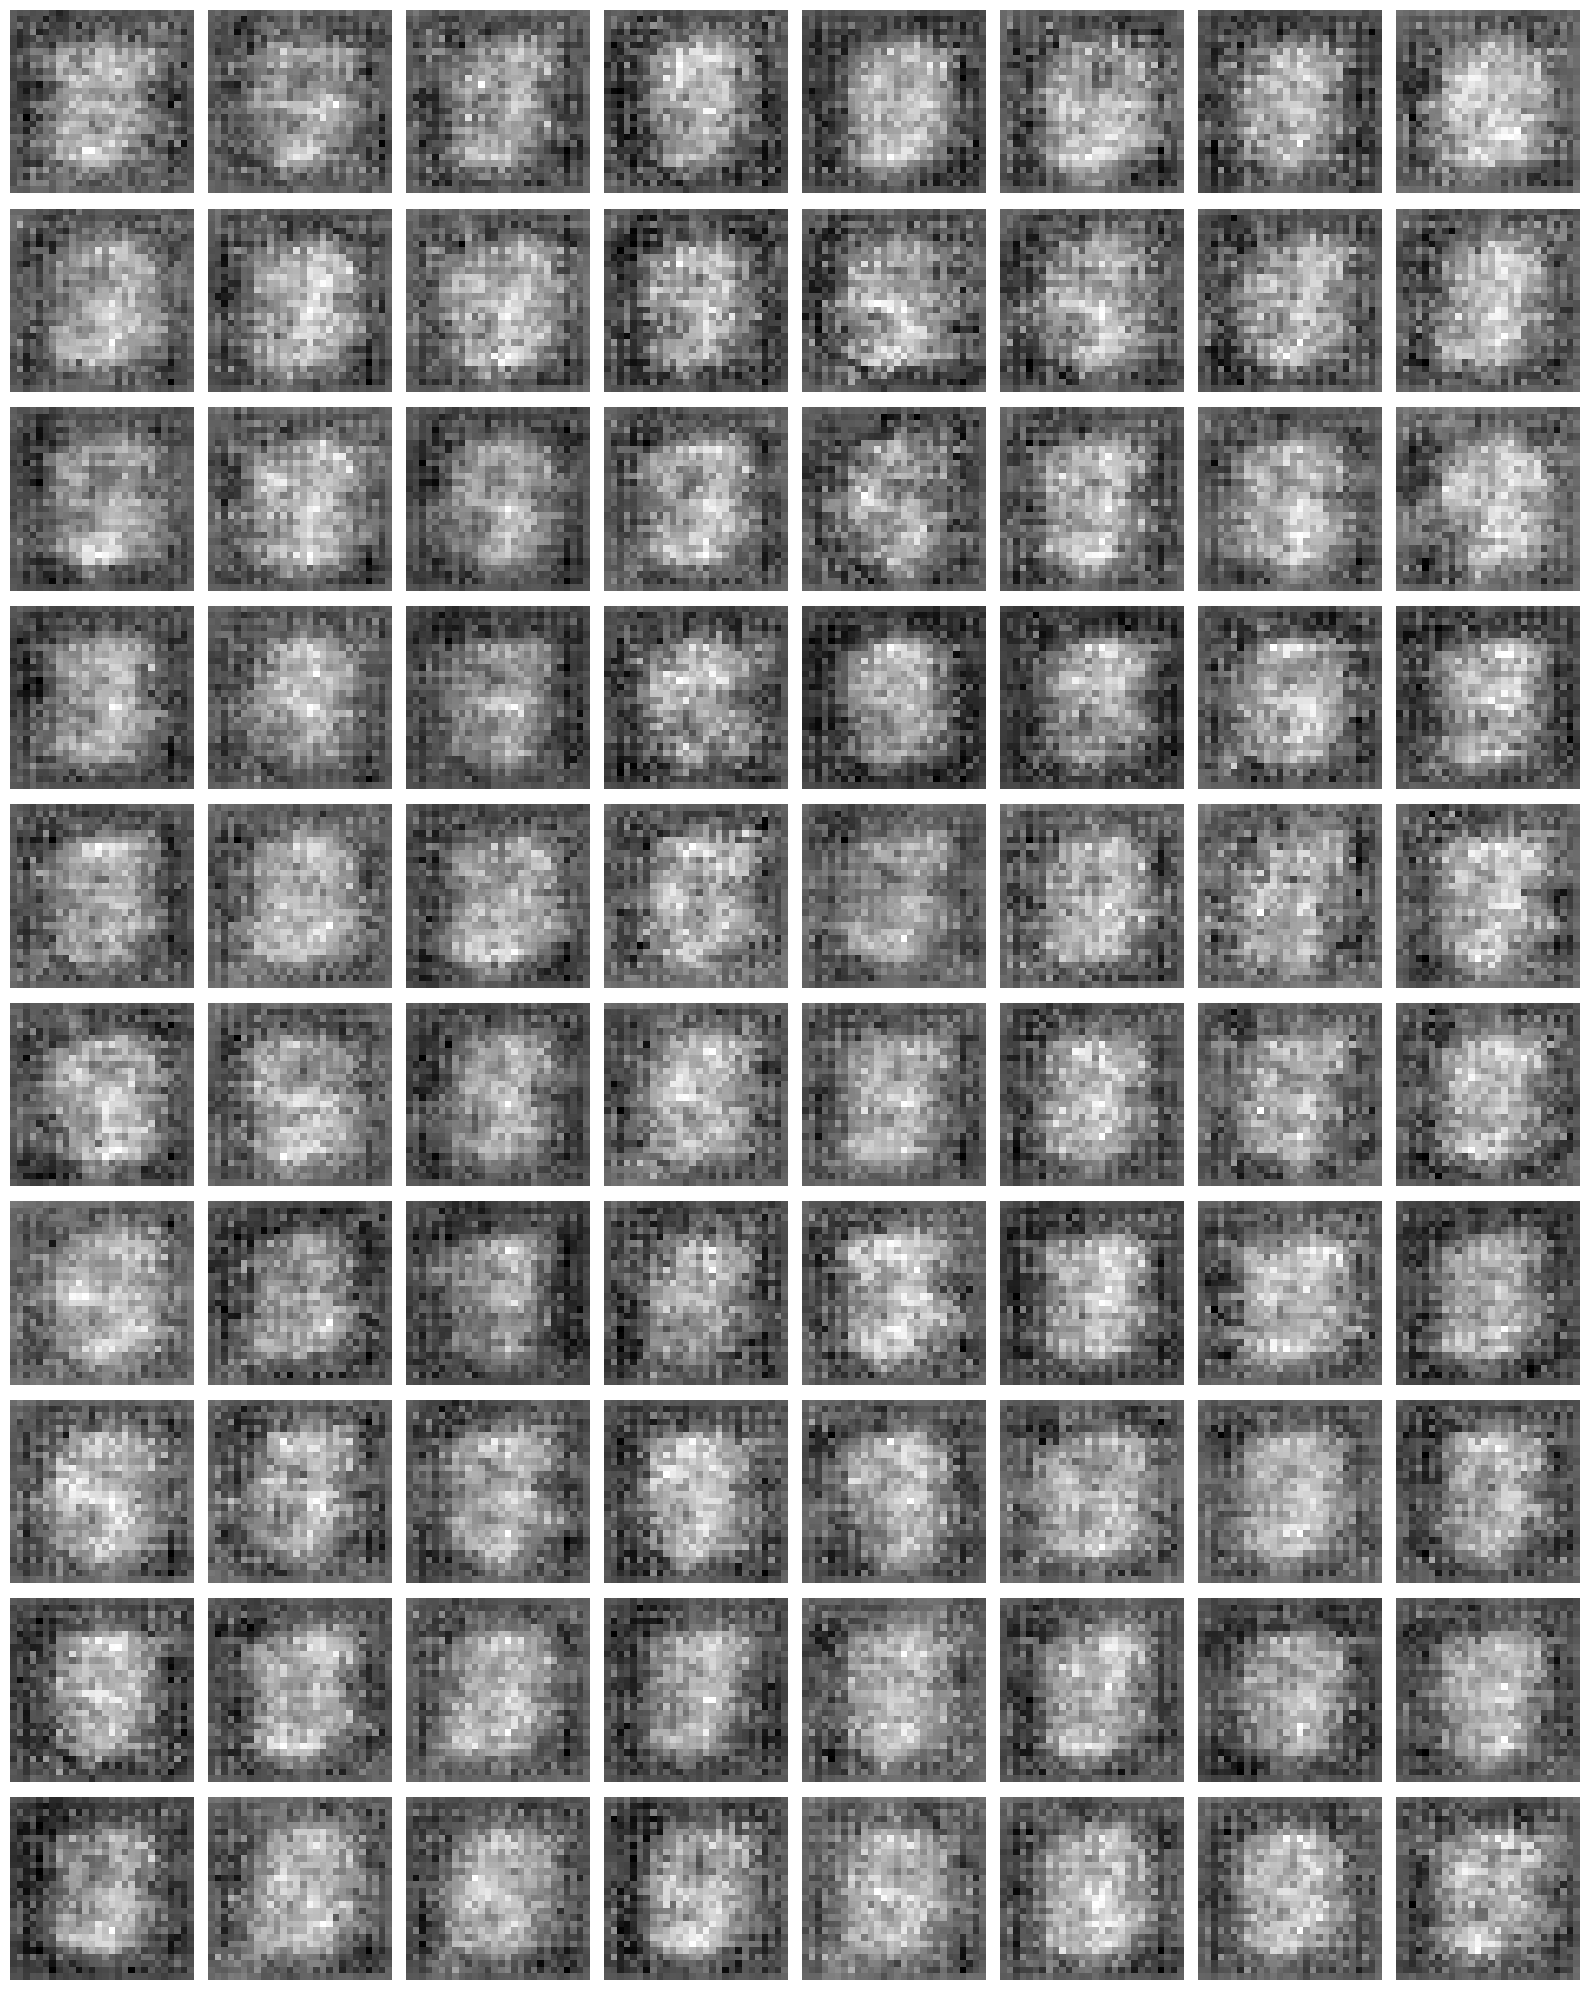

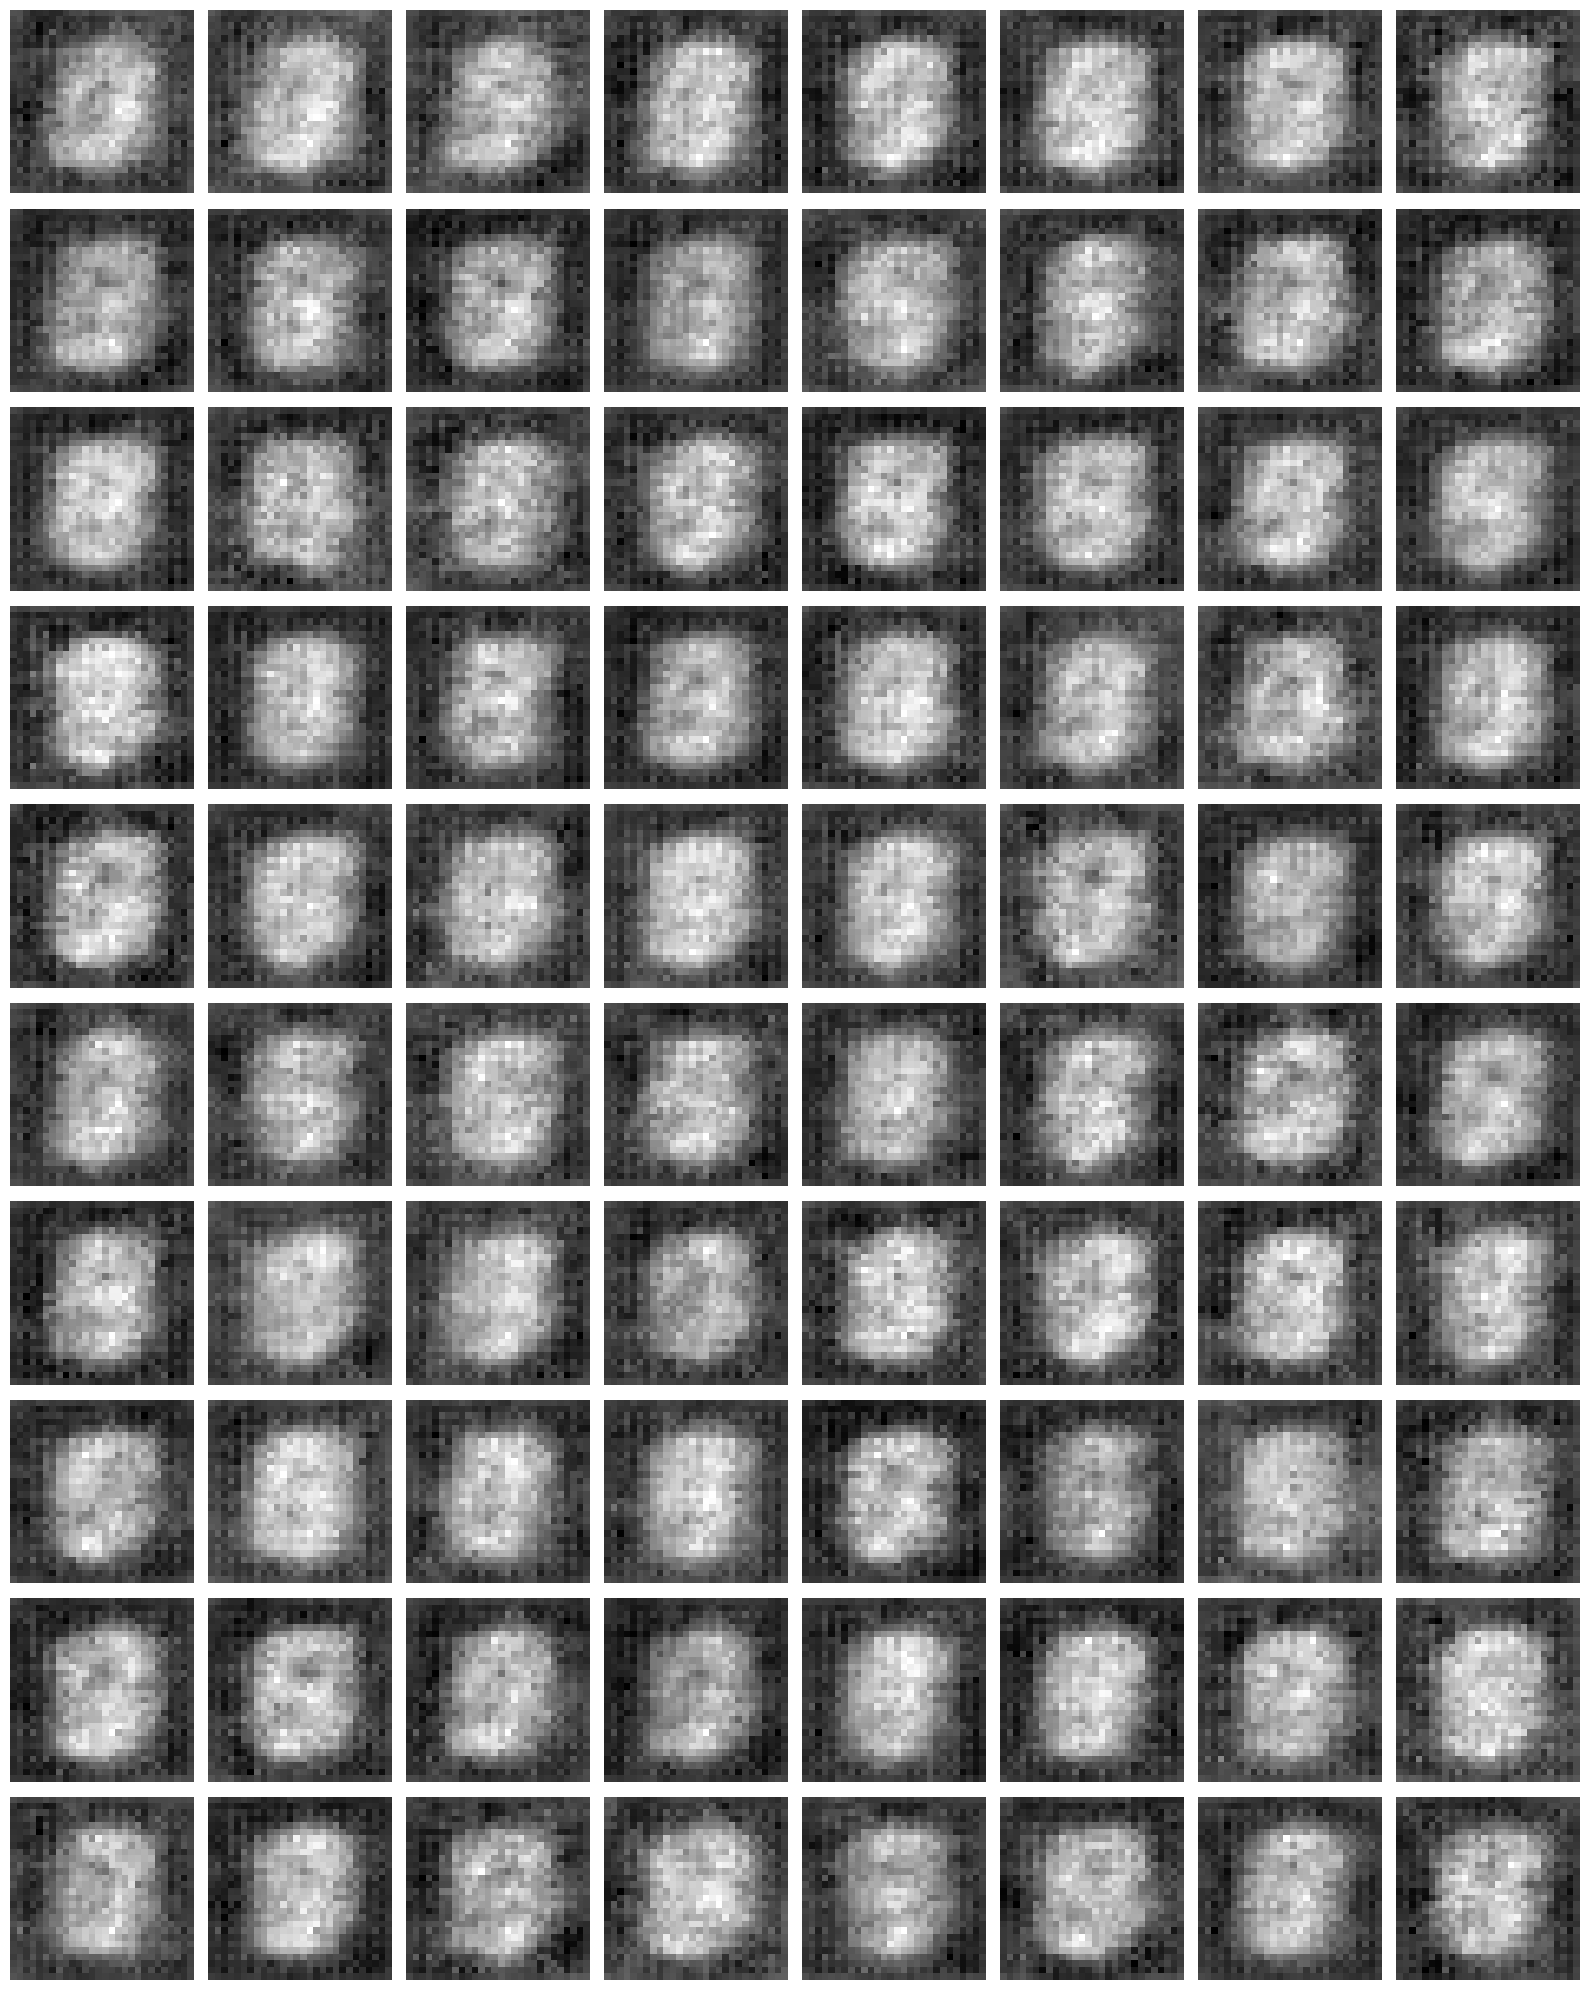

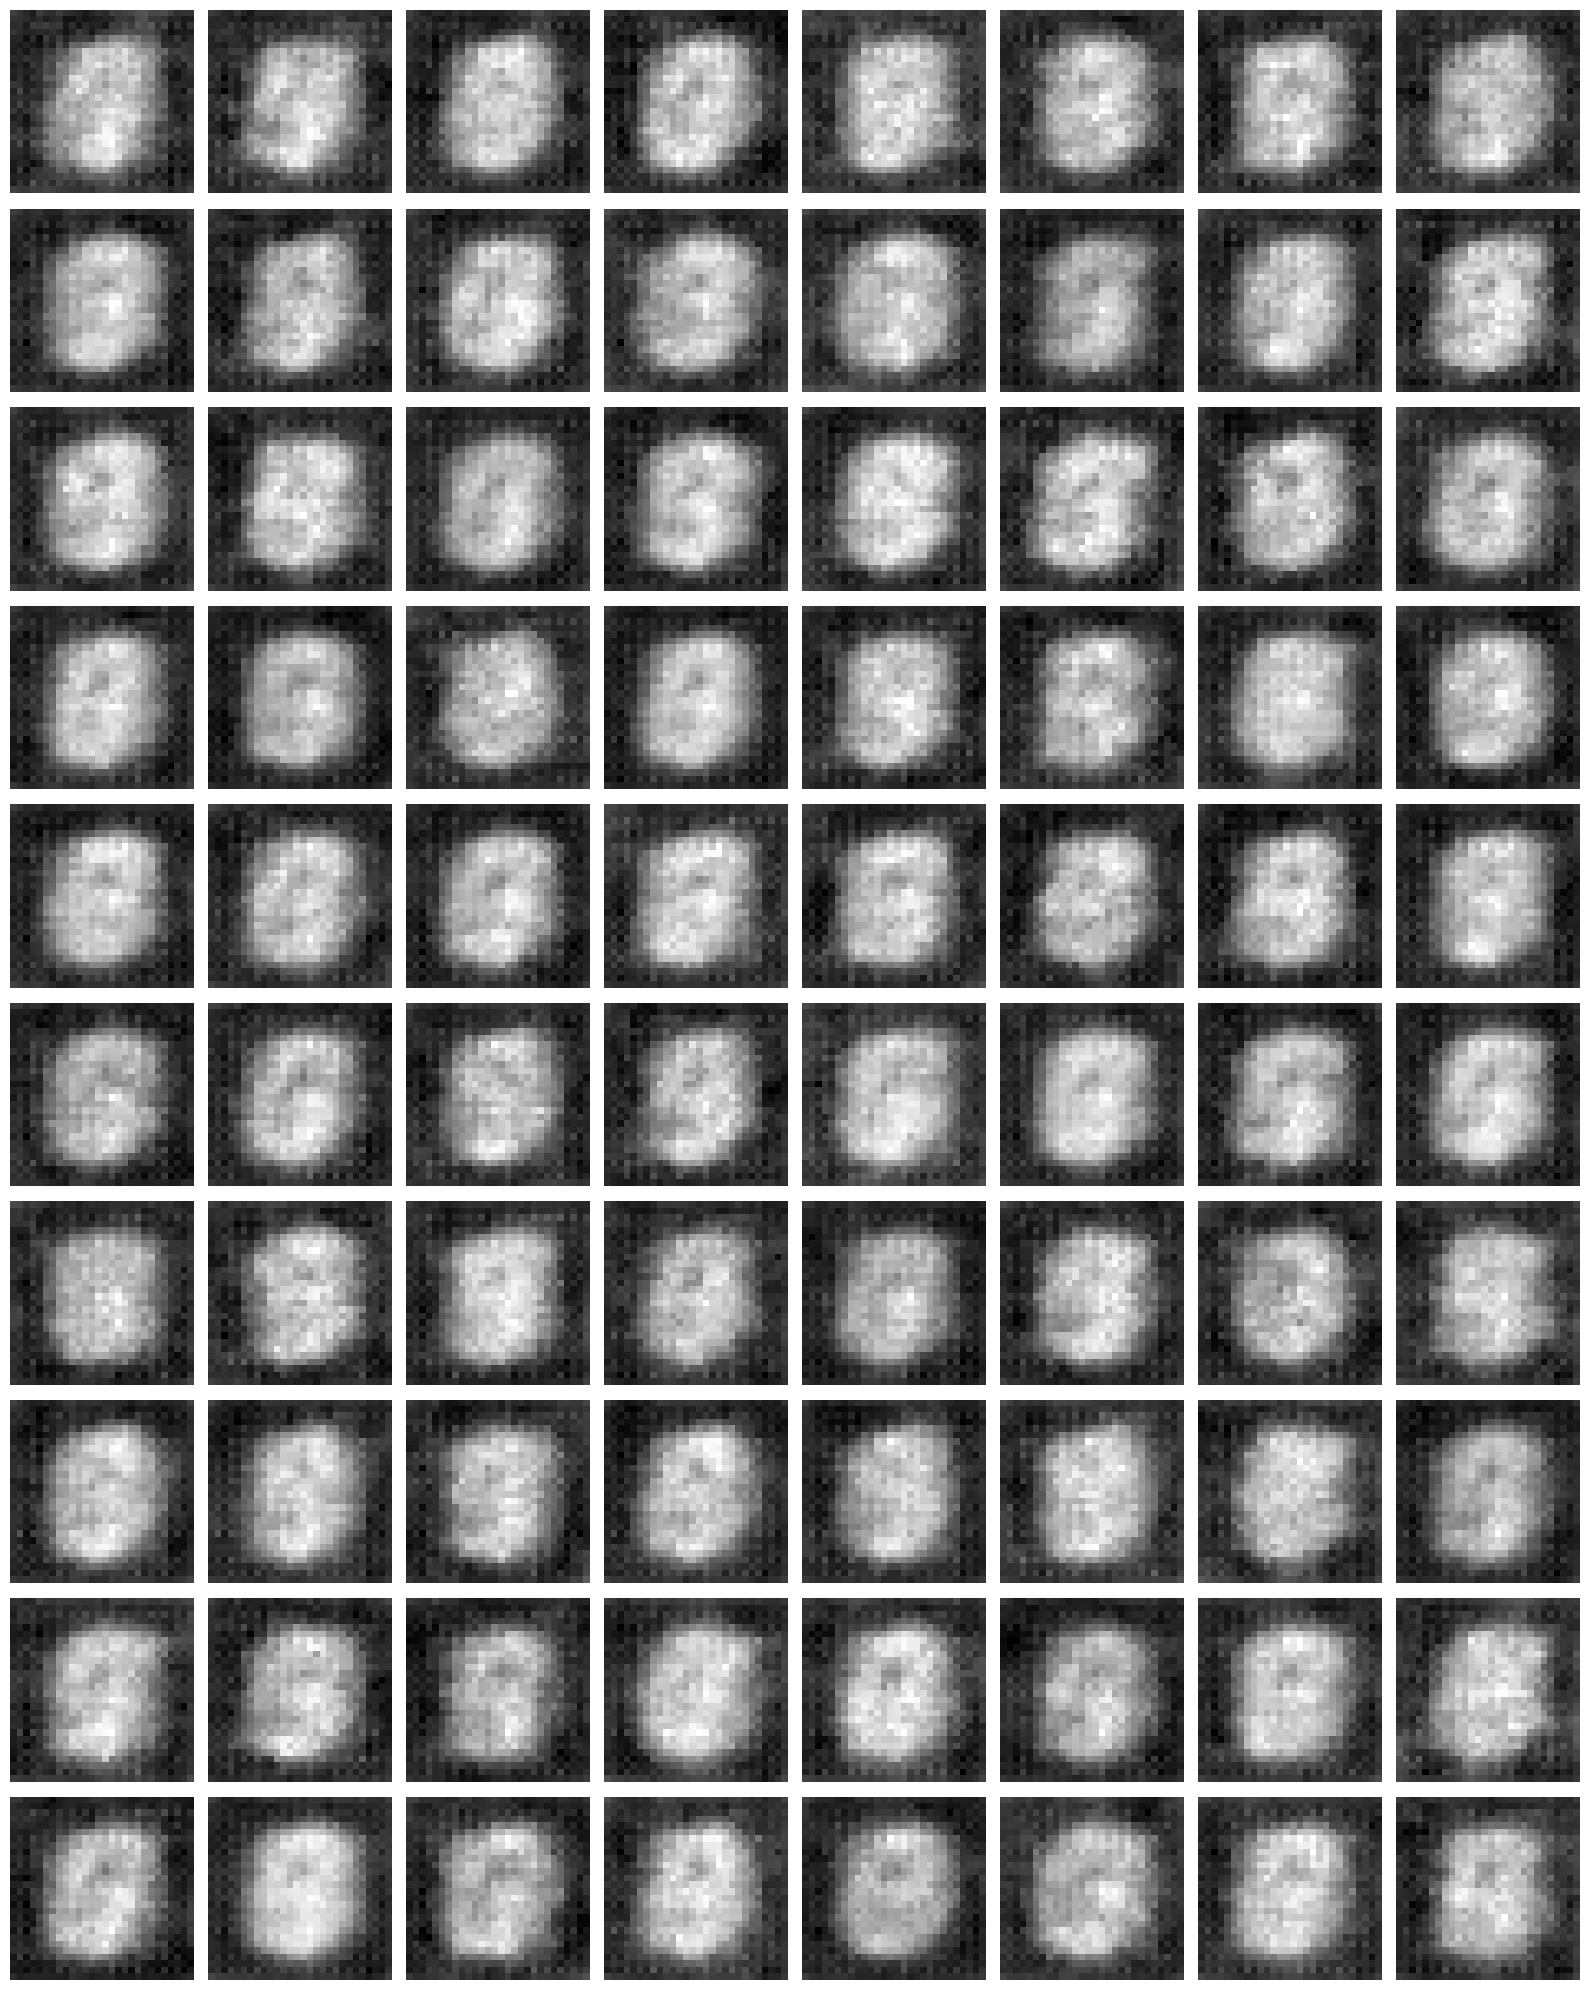

In [ ]:
import sys
import torch
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset, ConcatDataset, Subset
from torchvision.utils import make_grid
import torch.nn.functional as F


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import random

vae_path = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/Bingji_code"
sys.path.append(vae_path)

import models as models
import train_helper as train_helper
import utils as utils
import data_helper as data_helper

# Set up device and seed
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
base_seed = 0
torch.manual_seed(base_seed)
torch.cuda.manual_seed_all(base_seed)
np.random.seed(base_seed)
random.seed(base_seed)

ROOT = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/Bingji_code"

model_saved_path = os.path.join(ROOT,"model_saved")
data_saved_path = os.path.join(ROOT,"data_saved")
results_saved_path = os.path.join(ROOT,"results_saved")
picture_saved_path = os.path.join(ROOT,"picture_saved")

full_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transforms.ToTensor())

test_dataset = datasets.MNIST(root="./data", train=False, download=True,transform=transforms.ToTensor())
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)
full_digit_indices = utils.create_balanced_subset_indices(full_dataset,seed=base_seed)

#train_dataset_5000 = Subset(full_dataset, range(5000))
import torch
import torch.nn.functional as F

@torch.no_grad()
def generate_images_in_batches(model, total_samples, latent_dim, num_classes, batch_size=10000, device='cuda'):
    model.eval()
    generated_images = []
    all_labels = []

    # Balanced label assignment (always length = total_samples)
    labels_full = torch.arange(total_samples) % num_classes

    for start in range(0, total_samples, batch_size):
        end = min(start + batch_size, total_samples)
        n = end - start

        # Sample latent z
        z = torch.randn(n, latent_dim, device=device)

        # Labels
        y = labels_full[start:end]
        y_onehot = F.one_hot(y, num_classes=num_classes).float().to(device)

        # Decode logits → sigmoid → [0,1]
        logits_flat = model.decoder.decode(z, y_onehot)     # (n, 784), logits
        imgs = torch.sigmoid(logits_flat).view(-1, 1, 28, 28).cpu()

        generated_images.append(imgs)
        all_labels.append(y)

    images = torch.cat(generated_images, dim=0)
    labels = torch.cat(all_labels, dim=0)
    return images, labels

from FID import calculate_fid_score

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

@torch.no_grad()
def plot_model_samples(model, save_path=None, latent_dim=20, num_classes=10, per_class=8, device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device).eval()

    # latent + labels
    z = torch.randn(num_classes * per_class, latent_dim, device=device)
    y = torch.arange(num_classes, device=device).repeat_interleave(per_class)
    y_onehot = F.one_hot(y, num_classes=num_classes).float().to(device)

    # decode -> logits, then map to [0,1]
    logits_flat = model.decoder.decode(z, y_onehot)            # (n, 784), logits
    imgs = torch.sigmoid(logits_flat).view(-1, 1, 28, 28)      # tensor on device, no grad (due to @no_grad)

    # move for plotting
    imgs_np = imgs.detach().cpu().numpy()

    fig, axes = plt.subplots(num_classes, per_class, figsize=(2*per_class, 2*num_classes))
    for c in range(num_classes):
        for j in range(per_class):
            idx = c * per_class + j
            axes[c, j].imshow(imgs_np[idx].squeeze(), cmap='gray')
            axes[c, j].axis('off')
            if j == 0:
                axes[c, j].set_ylabel(f"Class {c}", fontsize=10)

    plt.tight_layout()
    if save_path:
        if not os.path.exists(os.path.dirname(save_path)):
            os.makedirs(os.path.dirname(save_path))
        plt.savefig(save_path, dpi=150)
        print(f"[SAVE] Sample grid saved -> {save_path}")
    return fig, axes


def fid(model):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    synthetic_gen_size = 6000
    gen_imgs_before_filter,y_before_filter = generate_images_in_batches(
        model=model,
        total_samples=synthetic_gen_size,
        latent_dim=20,
        num_classes=10,
        batch_size=10000,
        device=device
    )
    # Load synthetic data
    #synthetic = torch.load(f"data_saved/synthetic_mnist_cvae_{sample_size}_2.pt")
    images = gen_imgs_before_filter # [N, 1, 28, 28]
    labels = y_before_filter  # [N]

    transform = transforms.ToTensor()

    real_ds = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
    synthetic_ds = TensorDataset(images, labels)
    
    synthetic_ds = TensorDataset(images, labels)
    fid = calculate_fid_score(real_ds, synthetic_ds)
    
    return fid

import shutil

init_size = 500

all_models = []
test_results = {"val_loss":[], "val_recon":[], "val_kl":[], "fid":[],"model_name":[]}

# Seed real subset & train initial model
init_subset = utils.get_balanced_subset(full_digit_indices, init_size)
init_dataset = Subset(full_dataset, init_subset)
init_loader = DataLoader(init_dataset, batch_size=128, shuffle=True)

this_model = models.CVAE(input_dim=784, label_dim=10, latent_dim=20,
                         name=f"cvae_conv_real_{init_size}", arch="conv").to(device)
train_helper.train_model(this_model, init_loader, device, epochs=1, lr=1e-3, patience=5, verbose=False)
plot_model_samples(this_model, save_path=os.path.join(picture_saved_path,f"initial_model_samples_{init_size}.png"), device=device)
val_loss, val_recon, val_kl = train_helper.calculate_validation_loss(this_model, test_loader, device)
fid_score = fid(this_model)
test_results["val_loss"].append(val_loss)
test_results["val_recon"].append(val_recon)
test_results["val_kl"].append(val_kl)
test_results["fid"].append(fid_score)
test_results["model_name"].append(this_model.name)
print(f"Init loss: {init_size} - Val Loss: {val_loss:.4f} - Val KL: {val_kl:.4f} - Val Recon: {val_recon:.4f}")
all_models.append(this_model)

utils.save_model(this_model, this_model.get_name(), model_saved_path)

# ----- k-round synthetic retraining -----
k = 3                      # <-- number of retraining rounds
threshold = 0.1           # discriminator selection threshold
synthetic_size = 200_000         # list of synthetic attempt sizes to run per round

curr_model = this_model
for round_id in range(1, k + 1):
    # (A) Train a fresh discriminator for the CURRENT generator
    print(f"\n[Round {round_id}] Training discriminator for current model...")
    discriminator_dataset = data_helper.prepare_discriminator_dataset(full_dataset, curr_model, device)
    disc_loader = DataLoader(discriminator_dataset, batch_size=128, shuffle=True)
    disc_model = models.SyntheticDiscriminator(input_dim=784).to(device)
    train_helper.train_model(model=disc_model, train_loader=disc_loader, device=device,
                             epochs=1, lr=1e-3, patience=5, verbose=False)
    del disc_loader, discriminator_dataset
    # (B) Generate filtered synthetic dataset to a TEMP dir (unique per round)
    model_name = f'cvae_conv_q{threshold}_{synthetic_size}_r{round_id}'
    synthetic_data_load_path = os.path.join(data_saved_path, model_name)

    print(f"[Round {round_id}] Generating filtered synthetic data -> {synthetic_data_load_path}")
    data_helper.generate_balanced_images_with_filtering(
        model=curr_model,
        save_directory=synthetic_data_load_path,
        total_samples=synthetic_size,
        discriminator=disc_model,
        selection_threshold=threshold,
        verbose=False,
        use_quantile_filtering=True
    )

    synthetic_loader = data_helper.create_directory_based_dataloader(synthetic_data_load_path, batch_size=128)
    synthetic_model = models.CVAE(input_dim=784, label_dim=10, latent_dim=20,
                                    name=model_name, arch="conv").to(device)
    train_helper.train_model(synthetic_model, synthetic_loader, device,
                                epochs=1, lr=1e-3, patience=5, verbose=False)
    plot_model_samples(synthetic_model, save_path=os.path.join(picture_saved_path,f"round{round_id}_model_samples.png"), device=device)
    val_loss, val_recon, val_kl = train_helper.calculate_validation_loss(synthetic_model, test_loader, device)
    fid_score = fid(synthetic_model)
    test_results["val_loss"].append(val_loss)
    test_results["val_recon"].append(val_recon)
    test_results["val_kl"].append(val_kl)
    test_results["model_name"].append(synthetic_model.get_name())
    test_results["fid"].append(fid_score)
    print(f"[Round {round_id}] Model: {model_name} | Val Loss: {val_loss:.4f} | KL: {val_kl:.4f} | Recon: {val_recon:.4f} | FID: {fid_score:.4f}")

    utils.save_model(synthetic_model, synthetic_model.get_name(), model_saved_path)
    all_models.append(synthetic_model)

    # (D) Advance the chain
    curr_model = synthetic_model

    # (E) Cleanup temp dir
    del synthetic_loader
    try:
        if os.path.exists(synthetic_data_load_path):
            shutil.rmtree(synthetic_data_load_path)
            print(f"[CLEAN] Removed temp dir: {synthetic_data_load_path}")
    except Exception as e:
        print(f"[WARN] Failed to remove {synthetic_data_load_path}: {e}")

    # Optional: free GPU cache between rounds
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# Results table
res_table = pd.DataFrame.from_dict(test_results, orient='columns')
# save results table to results_saved_path
os.makedirs(results_saved_path, exist_ok=True)
res_table.to_csv(os.path.join(results_saved_path, f"results_table_{init_size}_{k}rounds.csv"), index=False)



In [2]:
os.makedirs(results_saved_path, exist_ok=True)
res_table.to_csv(os.path.join(results_saved_path, f"results_table_{init_size}_{k}rounds.csv"), index=False)

